In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [4]:
df=pd.read_csv(url)

In [5]:
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
343,2014,FORD,E150 VAN FFV,VAN - CARGO,4.6,8,A4,X,17.7,14.4,16.2,17,373
307,2014,DODGE,CHARGER AWD FFV,FULL-SIZE,3.6,6,A8,X,12.8,8.6,10.9,26,251
94,2014,BMW,435i COUPE,COMPACT,3.0,6,A8,Z,11.4,7.3,9.6,29,221
466,2014,GMC,TERRAIN AWD,SUV - SMALL,2.4,4,A6,X,11.5,8.2,10.0,28,230
633,2014,LAMBORGHINI,AVENTADOR COUPE,TWO-SEATER,6.5,12,A7,Z,22.8,12.9,18.3,15,421


In [6]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [7]:
cdf=df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
117,4.4,8,12.7,292
294,2.4,4,10.0,230
687,5.4,8,21.6,346
1020,1.8,4,8.7,200
987,1.8,4,4.8,110
885,3.8,6,11.9,274
195,6.2,8,12.0,276
446,5.3,8,22.6,362
867,3.4,6,10.3,237


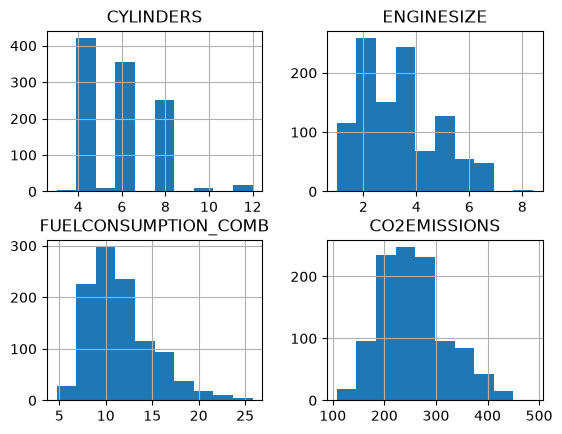

In [8]:
viz=cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

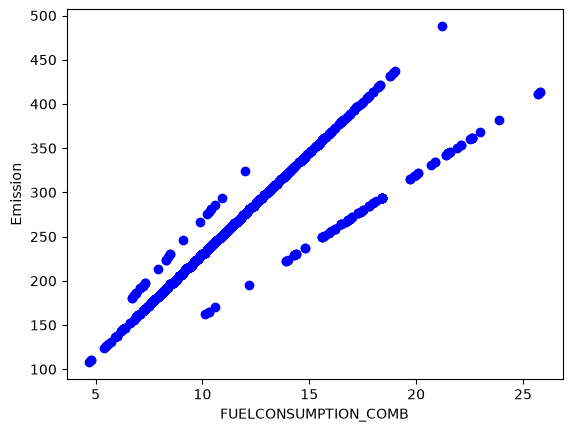

In [9]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

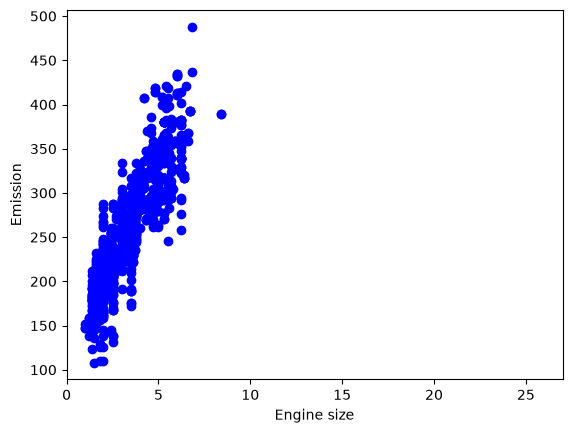

In [10]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

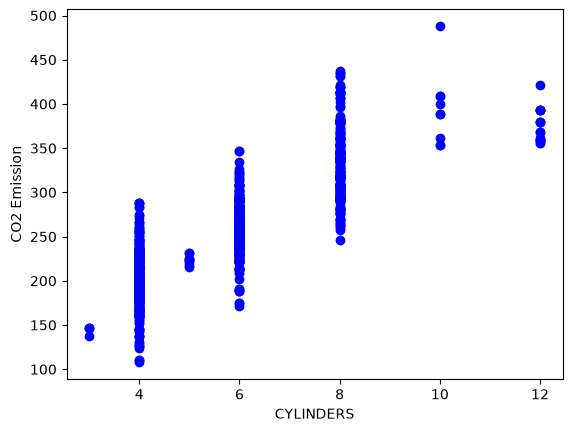

In [11]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("CYLINDERS")
plt.ylabel("CO2 Emission")
plt.show()

In [13]:
X=cdf.ENGINESIZE.to_numpy()
y=cdf.CO2EMISSIONS.to_numpy()

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
type(X_train), np.shape(X_train), type(y_train), np.shape(y_train)

(numpy.ndarray, (853,), numpy.ndarray, (853,))

In [17]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train.reshape(-1,1),y_train)

print ('Coefficients: ', model.coef_[0]) 
print ('Intercept: ',model.intercept_)

Coefficients:  38.992978724434074
Intercept:  126.28970217408721


Text(0, 0.5, 'Emission')

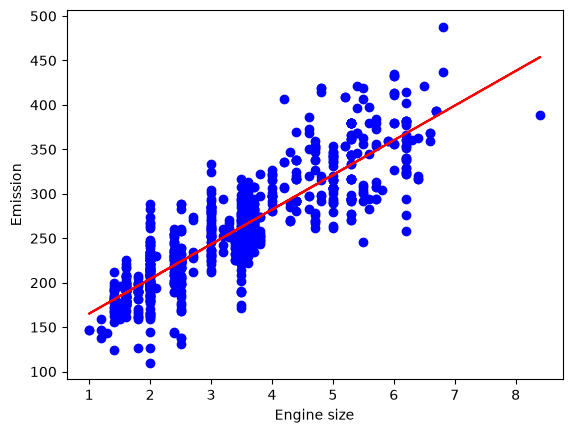

In [21]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, model.coef_ * X_train + model.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = model.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76
